<!--- sf-header --->
<table align="left">
<tr>
  <td style="text-align: center">
    <a href="https://console.cloud.google.com/vertex-ai/colab/import/https%3A%2F%2Fraw.githubusercontent.com%2Fstatmike%2Fscale-forecasting%2Fmain%2Fnotebooks%2F10_registry_operations_and_scale.ipynb">
      <img width="32px" src="https://lh3.googleusercontent.com/JmcxdQi-qOpctIvWKgPtrzZdJJK-J3sWE1RsfjZNwshCFgE_9fULcNpuXYTilIR2hjwN" alt="Colab Enterprise logo">
      <br>Run in<br>Colab Enterprise
    </a>
  </td>
</tr>
</table>
<br clear="left"/>

> **Run in Colab Enterprise:** click the badge to import this notebook, pick a runtime, and
> **Run all**. The Terraform-deployed templates already carry the `SF_*` run identity in their env,
> so there's no environment cell to fill in. Runs on the **`sf-main`** runtime template (Python 3.11). See
> [`docs/notebook_runtimes.md`](https://github.com/statmike/scale-forecasting/blob/main/docs/notebook_runtimes.md)
> for the per-notebook template mapping and the headless acceptance harness.


# 10 · Registry Operations, Pre-Flight Feasibility, All 5 Launch Pathways & Cross-Platform Run Review

This notebook covers **Day-2 production operations** (`Registry` and `Forecaster` in `sdk.py`), **pre-flight feasibility & repair/settle/cancel workflows**, **all 5 production launch pathways** (including live execution of the Cloud Composer 3 / Airflow `airflow_tasks` DAG sequence against a GCS-staged config), and **100,000-series multi-engine benchmark analysis** across Dataproc Spark, Vertex AI Ray, Vertex CustomJob, GCE, and BigQuery ML — **with zero raw SQL boilerplate**.

### At a glance
| Dimension | Details |
| :--- | :--- |
| **Learning outcomes** | Audit registry health (`reg.doctor()`), query the `v_run_summary` time ledger (`reg.runs_df()`), rehydrate runs for feasibility/cohort/repair previews (`retry`, `settle`, `cancel`), and execute all 5 launch pathways including Cloud Composer 3 `airflow_tasks`. |
| **Prerequisites** | Deployed `scale-forecasting` Google Cloud project (`SF_*` env vars) + `scale-forecasting[gcp]`. |
| **Estimated time** | ~3–6 minutes. |
| **Estimated run cost** | **Estimated `~\$0.05–\$0.20` USD** (BigQuery metadata queries + 5-series BigQuery ML `ARIMA_PLUS` & `TimesFM` execution in Act 4 + Cloud Storage staging). |
| **Ongoing cost** | **Zero compute when idle** for the Airflow task callables executed in Act 4. If you deploy a live **Cloud Composer 3** environment (`create_composer = true`, off by default), it bills continuously (`~\$300–\$400/month`) until disabled with `create_composer = false` (and its Cloud Storage bucket persists until deleted manually). |

```mermaid
flowchart TB
    subgraph Ops["Zero-SQL Registry & Operational Verbs (sdk.Registry · Forecaster)"]
        D1["reg.doctor() · reg.runs_df()<br/>Dataset, Views, Iceberg & Run Discovery"]
        D2["forecaster.feasibility() · cohorts_df() · jobs_df()<br/>Pre-Flight Fold Geometry & Job Sizing"]
        D3["forecaster.retry() · settle() · cancel()<br/>Preview-Safe Repair & Drain Verbs"]
        D4["reg.probe(run_id) · snapshot() · export()<br/>Live Platform Probes & Time-Travel Clones"]
    end
    subgraph Pathways["All 5 Production Launch Pathways"]
        L1["1. Python SDK: Forecaster(cfg).run_live()"]
        L2["2. CLI & Cloud Batch: launch_plan.stage_run(cfg)"]
        L3["3. Cloud Composer 3: emit_airflow() + airflow_tasks.*"]
        L4["4. Spark Connect: Forecaster.run(spark=session)"]
        L5["5. Direct Cluster Embedding: spark_io.run_group / ray_io.chunk_cells"]
    end
    Ops & Pathways --> SCALE["Cross-Platform Run Review<br/>reg.runs_df(status='COMPLETED')"]
```

## Act 1 · Cloud Bootstrap & Deployment Resolution

On a managed cloud notebook (**Colab Enterprise**, **Vertex AI Workbench**) the bootstrap cell below clones or updates the repository and installs the locked dependency set (`uv.lock`) into an isolated `.colab-deps` prefix so `import scale_forecasting` resolves against the exact package versions every cloud worker uses. **In a local clone with `.venv`, this cell is a fast no-op.**

In [1]:
# Cloud bootstrap: clone + install the LOCKED dependency set (uv.lock) so
# `import scale_forecasting` resolves against the exact versions every other surface runs.
import importlib.util
import os
import shutil
import subprocess
import sys

REPO_URL = os.environ.get("SF_REPO_URL", "https://github.com/statmike/scale-forecasting.git")
REPO_DIR = os.environ.get("SF_REPO_DIR", "scale-forecasting")
EXTRAS = ['gcp']

if importlib.util.find_spec("scale_forecasting") is None:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    uv = shutil.which("uv")
    if uv is None:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "uv"], check=True)
        uv = shutil.which("uv") or "uv"
    reqs = os.path.abspath(os.path.join(REPO_DIR, "colab-requirements.txt"))
    extra_flags = [f for e in EXTRAS for f in ("--extra", e)]
    subprocess.run(
        [uv, "export", "--frozen", "--no-emit-project", "--no-hashes", "--no-dev", *extra_flags, "-o", reqs],
        cwd=REPO_DIR,
        check=True,
    )
    target = os.path.abspath(os.path.join(REPO_DIR, ".colab-deps"))
    subprocess.run(
        [uv, "pip", "install", "--python", sys.executable, "--target", target, "-r", reqs],
        check=True,
    )
    sys.path.insert(0, target)
    sys.path.insert(0, os.path.join(REPO_DIR, "src"))
    print("installed scale_forecasting from", REPO_DIR)
else:
    print("scale_forecasting already importable — skipping bootstrap")

scale_forecasting already importable — skipping bootstrap


### Resolve the Live GCP Deployment (`Settings.resolve()`)

`Settings.resolve()` reads the `SF_*` environment variables (`SF_PROJECT_ID`, `SF_REGION`, `SF_DATASET_ID`, `SF_WAREHOUSE_URI`, `SF_CONNECTION`, `SF_COMPUTE_SA`) pre-populated by Terraform in the `sf-main` runtime template (or your local shell).

In [2]:
from google.cloud import bigquery
from scale_forecasting.settings import Settings

settings = Settings.resolve()
client = bigquery.Client(project=settings.project_id)
DATASET = settings.dataset_ref
print(f"Deployment: {DATASET} | Region: {settings.region} | Bucket: {settings.warehouse_uri}")

Deployment: statmike-scale-forecasting.scale_forecasting | Region: us-central1 | Bucket: gs://statmike-scale-forecasting-warehouse/warehouse


## Act 2 · Registry Health Audit (`reg.doctor()`) & Zero-SQL Run Discovery (`reg.runs_df()`)

`Registry(settings=settings).doctor()` performs a non-destructive read-only audit of all 5 registry tables, 5 analytical SQL views, in-flight `RUNNING` rows, and orphaned GCS artifact prefixes. `reg.runs_df(limit=10)` returns the recent run ledger from `v_run_summary` as a clean DataFrame without writing a single line of SQL.

In [3]:
import pandas as pd
from scale_forecasting import Forecaster, Registry, RunConfig

reg = Registry(settings=settings)
report = reg.doctor()
print("Registry healthy:", report.healthy)
display(pd.DataFrame([
    {"table": t.table, "exists": t.exists, "rows": t.rows}
    for t in report.tables
]))

# Zero-SQL discovery of the 10 most recent runs from v_run_summary
recent_df = reg.runs_df(limit=10)
display(recent_df)

Registry healthy: True


,table,exists,rows
0,run_registry,True,339
1,run_jobs,True,616
2,forecast_metadata,True,5491676
3,forecast_predictions,True,153713600
4,backtest_oof,True,11016892


,run_id,created_at,status,python_runtime,n_series,n_models,backtest_on,runtime_seconds,n_jobs,longest_job_seconds,jobs_seconds,jobs_span_seconds,overhead_seconds,overhead_fraction,dcu_milli_seconds
0,nb08-master-workflow-1791391142-5a9fc342dacc,2026-10-07 16:39:21.318005+00:00,COMPLETED,spark,15,7,True,500.951105,5,455.399,1453.497,490.366,34.967,0.071308,2814000.0
1,nb05-covariates-global-1791391135-dfcbfde016ec,2026-10-07 16:39:15.091779+00:00,COMPLETED,vertex,20,5,True,425.927678,4,383.952,1139.657,415.251,31.299,0.075374,NaN
2,nb02-vertex-gce-1791391131-8a67037d28fd,2026-10-07 16:39:11.229555+00:00,COMPLETED,vertex,15,3,True,438.080862,3,396.308,800.193,428.461,32.153,0.075043,NaN
3,nb10-airflow-dag-1791391074-6474df21fdf6,2026-10-07 16:38:49.071872+00:00,COMPLETED,spark,5,2,True,97.618010,2,101.005,119.704,165.874,64.869,0.391074,NaN
4,smoke-42-vertex-automl-tabular-workflow-d3fea0...,2026-10-07 12:15:49.688848+00:00,COMPLETED,vertex_automl,20,3,True,7766.889912,4,7725.194,8600.669,7756.868,31.674,0.004083,NaN
5,smoke-41-gke-ray-f9c3cd840845,2026-10-06 01:31:23.105112+00:00,COMPLETED,gke,20,4,True,155.344039,4,120.341,310.433,143.770,23.429,0.162962,NaN
6,smoke-40-gke-indexed-job-c593ae5b6035,2026-10-06 01:20:45.287432+00:00,COMPLETED,gke,20,4,True,502.867512,4,467.709,1049.509,492.058,24.349,0.049484,NaN
7,gke-demo-4886e298cb99,2026-10-06 01:12:32.312163+00:00,COMPLETED,gke,6,4,True,367.845547,2,356.547,429.503,359.305,2.758,0.007676,NaN
8,smoke-38-vertex-custom-job-82b620bbd9ba,2026-10-05 21:58:06.642873+00:00,COMPLETED,vertex,20,7,True,2967.132993,2,2929.933,2949.545,2955.437,25.504,0.008630,NaN
9,smoke-01-serverless-cpu-7a3d4234e0e1,2026-10-05 19:15:29.393720+00:00,COMPLETED,spark,100,3,False,1950.525031,2,1938.402,3430.191,1939.812,1.410,0.000727,13672125.0


## Act 3 · Reattach to Any Historical `run_id`: Feasibility, Cohorts, Attributions, Jobs & Safe Repair Previews

`Forecaster.from_run_id(RUN_ID, settings=settings)` rehydrates a `Forecaster` directly from the stored `config_json` in `run_registry`.
From that rehydrated instance, we can inspect:
1. **Pre-Flight Feasibility (`hist_forecaster.feasibility()`):** Audits source series history lengths against the required backtest fold geometry.
2. **Cohort Health, Feature Attributions & Job Sizing (`cohorts_df()`, `attributions_df()`, `jobs_df()`, `reg.probe()`):** Inspects fold coverage, stored Two-Tier feature attributions, executed VM/cluster sizing, and live platform probes.
3. **Preview-Mode Operational Verbs (`retry(confirm=False)`, `settle(yes=False)`, `cancel(confirm=False)`):** Dry-runs the repair classifier, drain-and-ensemble settler, and job cancellation plan without mutating any state.

Selected run_id: smoke-42-vertex-automl-tabular-workflow-d3fea0c6efc5


,rank,model_type,family,is_ensemble,ensemble_id,compute_engine,n_series,decision_metric,score,pooled_wape,...,mean_mae,mean_rmse,mean_coverage,mean_interval_score,mean_fit_seconds,median_fit_seconds,no_artifact_rate,n_predictions,lift_vs_best_base,lift_pct
0,1,ensemble_inverse_error,ensemble,True,fdbc4b03f8ab,ensemble,20,rmsse,0.672149,0.115980,...,11.408516,16.177951,NaN,NaN,NaN,NaN,1.0,280,0.050535,0.069927
1,2,ensemble_nnls,ensemble,True,fdbc4b03f8ab,ensemble,20,rmsse,0.700724,0.123185,...,12.117246,17.131974,NaN,NaN,NaN,NaN,0.0,280,0.021961,0.030388
2,3,ensemble_mean,ensemble,True,fdbc4b03f8ab,ensemble,20,rmsse,0.708368,0.125735,...,12.368028,17.298929,NaN,NaN,NaN,NaN,1.0,280,0.014316,0.019810
3,4,arima_plus,native,False,None,bigquery,20,rmsse,0.722685,0.123176,...,12.116322,17.604665,0.578571,71.961057,NaN,NaN,1.0,560,NaN,NaN
4,5,xgboost,ml,False,None,vertex,20,rmsse,0.831709,0.148231,...,14.580873,19.826099,0.175000,121.162970,3.078804,1.761049,1.0,560,NaN,NaN
5,6,vertex_tide,automl,False,None,vertex_automl,20,rmsse,0.928903,0.156401,...,15.384542,20.520700,0.000000,NaN,384.740991,384.740991,0.0,280,NaN,NaN


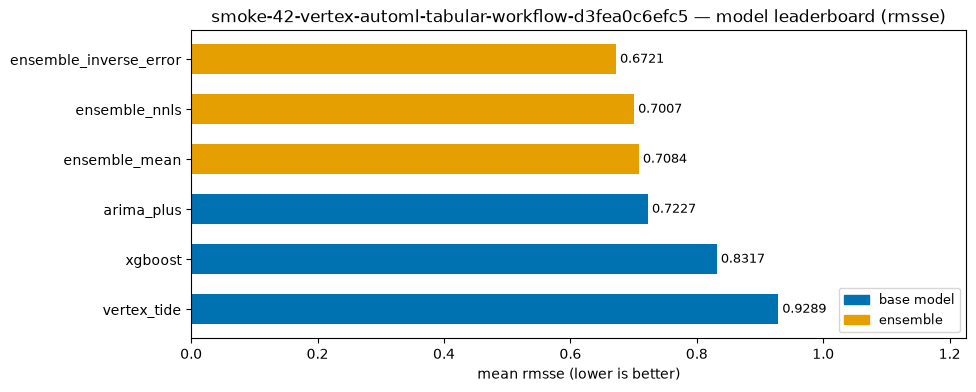

--- Pre-Flight Fold Feasibility Report (hist_forecaster.feasibility) ---


feasibility: 20 series x 3 models = 60 cells
  fits: 120 (174,360 training rows) = 1.990 whole-history fits per cell
  1 of 1 folds: 20 series (100.0%) — all folds
  min_train=180 is within budget: up to 1446 still keeps 90% of series at full folds
--- Backtest Cohort Coverage, Feature Attributions & Per-Family Job Telemetry ---


,model_type,family,is_ensemble,n_series,score,pooled_wape,n_comparable_series,n_full,n_reduced,n_unscored,n_failed,n_not_requested,fold_histogram,refit_modes,staleness_gap
0,ensemble_inverse_error,ensemble,True,20,0.672149,0.115980,20,0,0,0,0,20,none,per_fold:20,None
1,ensemble_nnls,ensemble,True,20,0.700724,0.123185,20,0,0,0,0,20,none,per_fold:20,None
2,ensemble_mean,ensemble,True,20,0.708368,0.125735,20,0,0,0,0,20,none,per_fold:20,None
3,arima_plus,native,False,20,0.722685,0.123176,20,20,0,0,0,0,1f:20,per_fold:20,None
4,xgboost,ml,False,20,0.831709,0.148231,20,20,0,0,0,0,1f:20,per_fold:20,None
5,vertex_tide,automl,False,20,0.928903,0.156401,20,20,0,0,0,0,1f:20,per_fold:20,None


,ts_id,model_type,compute_engine,feature,importance
0,s_000000,vertex_tide,vertex_automl,y,139.508250
1,s_000000,vertex_tide,vertex_automl,price_index,10.309466
2,s_000000,vertex_tide,vertex_automl,region,9.580043
3,s_000000,vertex_tide,vertex_automl,temperature,9.023960
4,s_000000,vertex_tide,vertex_automl,category,5.462731
5,s_000000,vertex_tide,vertex_automl,ds,4.295054
6,s_000000,vertex_tide,vertex_automl,promo_flag,2.469004
7,s_000000,vertex_tide,vertex_automl,is_holiday,0.378347
8,s_000000,xgboost,vertex,lag_7,0.811921
9,s_000000,xgboost,vertex,is_holiday,0.052039


,family,job_key,system_job_id,runtime,status,attempt,hardware,gpu_type,spark_mode,runtime_seconds
0,automl,sf-smoke-42-vertex-automl-tabular-workflow-d3f...,sf-ex-automl-tabular-workflow-d3fea0c6efc5-aut...,vertex_automl,COMPLETED,3,cpu,None,None,7721.962655
1,ensemble,sf-smoke-42-vertex-automl-tabular-workflow-d3f...,sf-smoke-42-vertex-automl-tabular-workflow-d3f...,bigquery,COMPLETED,3,None,None,None,17.515806
2,ml,sf-smoke-42-vertex-automl-tabular-workflow-d3f...,projects/307701787156/locations/us-central1/cu...,vertex,COMPLETED,3,cpu,None,None,812.377340
3,native,sf-smoke-42-vertex-automl-tabular-workflow-d3f...,sf-smoke-42-vertex-automl-tabular-workflow-d3f...,bigquery,COMPLETED,3,None,None,None,36.761728


Platform job probes: ProbeReport(run_id='smoke-42-vertex-automl-tabular-workflow-d3fea0c6efc5', status='COMPLETED', escalated=False, families=(FamilyVerdict(family='ml', runtime='vertex', registry_status='COMPLETED', native_state=None, exists=None, verdict='TRUST_REGISTRY', disagreement=False, n_done=20, n_expected=20, detail='', telemetry={}), FamilyVerdict(family='automl', runtime='vertex_automl', registry_status='COMPLETED', native_state=None, exists=None, verdict='TRUST_REGISTRY', disagreement=False, n_done=20, n_expected=20, detail='', telemetry={}), FamilyVerdict(family='native', runtime='bigquery', registry_status='COMPLETED', native_state=None, exists=None, verdict='TRUST_REGISTRY', disagreement=False, n_done=20, n_expected=20, detail='', telemetry={}), FamilyVerdict(family='ensemble', runtime='bigquery', registry_status='COMPLETED', native_state=None, exists=None, verdict='TRUST_REGISTRY', disagreement=False, n_done=60, n_expected=60, detail='', telemetry={})), disagreement=Fa

Retry preview executed: False | verdict counts: {'SKIP_ALREADY_DONE': 60} | submittable models: ()


Settle preview: SettleReport(run_id='smoke-42-vertex-automl-tabular-workflow-d3fea0c6efc5', plan=SettlePlan(run_id='smoke-42-vertex-automl-tabular-workflow-d3fea0c6efc5', header_status='COMPLETED', items=(SettleItem(family='ml', runtime='vertex', registry_status='COMPLETED', verdict='TRUST_REGISTRY', native_state=None, n_done=20, n_expected=20, decision=None, note='already COMPLETED, untouched'), SettleItem(family='automl', runtime='vertex_automl', registry_status='COMPLETED', verdict='TRUST_REGISTRY', native_state=None, n_done=20, n_expected=20, decision=None, note='already COMPLETED, untouched'), SettleItem(family='native', runtime='bigquery', registry_status='COMPLETED', verdict='TRUST_REGISTRY', native_state=None, n_done=20, n_expected=20, decision=None, note='already COMPLETED, untouched'), SettleItem(family='ensemble', runtime='bigquery', registry_status='COMPLETED', verdict='TRUST_REGISTRY', native_state=None, n_done=60, n_expected=60, decision=None, note='already COMPLETED, unt

Cancel preview: CancelReport(run_id='smoke-42-vertex-automl-tabular-workflow-d3fea0c6efc5', plan=CancelPlan(run_id='smoke-42-vertex-automl-tabular-workflow-d3fea0c6efc5', items=(CancelPlanItem(family='ml', runtime='vertex', registry_status='COMPLETED', native_state=None, cancellable=False, n_done=20, n_expected=20, note='already COMPLETED, untouched'), CancelPlanItem(family='automl', runtime='vertex_automl', registry_status='COMPLETED', native_state=None, cancellable=False, n_done=20, n_expected=20, note='already COMPLETED, untouched'), CancelPlanItem(family='native', runtime='bigquery', registry_status='COMPLETED', native_state=None, cancellable=False, n_done=20, n_expected=20, note='already COMPLETED, untouched'), CancelPlanItem(family='ensemble', runtime='bigquery', registry_status='COMPLETED', native_state=None, cancellable=False, n_done=60, n_expected=60, note='already COMPLETED, untouched')), ensemble_suppressed=False), executed=False, outcomes=(), header_status=None, actor=None,

In [4]:
import matplotlib.pyplot as plt
from scale_forecasting import plot_leaderboard

RUN_ID = None  # None -> auto-select most recent COMPLETED run
if RUN_ID is None and not recent_df.empty:
    completed = recent_df[recent_df["status"] == "COMPLETED"]
    RUN_ID = str((completed if not completed.empty else recent_df)["run_id"].iloc[0])

print("Selected run_id:", RUN_ID)
if RUN_ID:
    hist_forecaster = Forecaster.from_run_id(RUN_ID, settings=settings)
    display(hist_forecaster.leaderboard_df())
    plot_leaderboard(hist_forecaster.review_run())
    plt.show()

    print("--- Pre-Flight Fold Feasibility Report (hist_forecaster.feasibility) ---")
    feas = hist_forecaster.feasibility()
    print("\n".join(feas))

    print("--- Backtest Cohort Coverage, Feature Attributions & Per-Family Job Telemetry ---")
    display(hist_forecaster.cohorts_df())
    hist_attr = hist_forecaster.attributions_df(level="global")
    if not hist_attr.empty:
        display(hist_attr.head(10))
    display(hist_forecaster.jobs_df())
    print("Platform job probes:", reg.probe(RUN_ID))

    print("--- Safe Preview-Mode Day-2 Verbs (confirm=False / yes=False) ---")
    retry_preview = hist_forecaster.retry(confirm=False)
    print("Retry preview executed:", retry_preview.executed, "| verdict counts:", retry_preview.plan.counts, "| submittable models:", retry_preview.plan.models)
    settle_preview = hist_forecaster.settle(yes=False)
    print("Settle preview:", settle_preview)
    cancel_preview = hist_forecaster.cancel(confirm=False)
    print("Cancel preview:", cancel_preview)

## Act 4 · All 5 Production Launch Pathways & Live Cloud Composer 3 (`airflow_tasks`) Execution

`scale-forecasting` executes the **exact same `RunConfig`** across all **5 launch surfaces**:
1. **Python SDK (`Forecaster`):** `Forecaster(cfg).run()` / `Forecaster(cfg).run_live()` (used throughout Notebooks `01`–`08`).
2. **CLI & Headless Cloud Batch (`launch_plan.stage_run`):** Uploads `src.zip` + `config.json` to GCS (`gs://<code_bucket>/runs/<run_id>.json`) and emits the exact `python -m scale_forecasting.main` and `gcloud` commands for Cloud Batch / Cloud Run Jobs.
3. **Cloud Composer 3 / Apache Airflow (`emit_airflow` + `airflow_tasks`):** Generates a self-contained Airflow DAG whose `PythonOperator` nodes call `scale_forecasting.airflow_tasks` (`begin_run` $\rightarrow$ `run_family` / `run_native` $\rightarrow$ `retry_families` $\rightarrow$ `run_ensemble` $\rightarrow$ `finalize_run`).
4. **Interactive Spark Connect (`Forecaster.run(spark=spark)`):** Drives a remote Dataproc 2.3 cluster over gRPC (Notebook `03`).
5. **Direct Cluster Engine Embedding (`spark_io.run_group` & `ray_io.chunk_cells`):** Embeds the pure worker UDF inside an existing Spark or Ray pipeline (Notebooks `03` & `04`).

Below, we stage a production `RunConfig` to GCS with `stage_run()`, emit its Cloud Composer 3 DAG `.py` source with `emit_airflow()`, and **execute the exact `airflow_tasks` DAG node sequence live** against the GCS-staged `config_uri`!

In [5]:
import time
from scale_forecasting import airflow_tasks, launch_plan

dag_cfg = RunConfig(
    run_name=f"nb10 airflow dag {int(time.time())}",
    data={"source_table": "source_series_native", "horizon": 14, "series_limit": 5},
    models=["arima_plus", "timesfm"],
    features={"holidays": ["US"]},
    backtest={"enabled": True, "n_folds": 2, "horizon": 14, "step": 14},
    ensemble={"enabled": True, "strategies": ["mean", "inverse_error", "nnls"]},
)
dag_forecaster = Forecaster(dag_cfg, settings=settings)

# Pathway 2: Stage config + code archive to GCS via launch_plan.stage_run()
staged_plan = launch_plan.stage_run(dag_cfg, settings=settings)
print("Staged config_uri:", staged_plan.config_uri)
print("Emitted CLI command:", staged_plan.commands["main"].universal)

# Pathway 3A: Emit the Cloud Composer 3 / Airflow DAG Python file
dag_source = dag_forecaster.emit_airflow(with_retry=True)
print("\n--- Generated Cloud Composer 3 DAG (first 30 lines) ---")
print("\n".join(dag_source.splitlines()[:30]))

# Pathway 3B: Execute the exact Airflow TaskFlow node sequence live against staged_plan.config_uri!
print("\n--- Executing Airflow DAG Task Callables Live (begin_run -> run_native -> retry_families -> run_ensemble -> finalize_run) ---")
dag_run_id = airflow_tasks.begin_run(staged_plan.config_uri)
airflow_tasks.run_native(staged_plan.config_uri)
retry_msg = airflow_tasks.retry_families(staged_plan.config_uri)
print("Airflow retry node:", retry_msg)
airflow_tasks.run_ensemble(staged_plan.config_uri)
airflow_tasks.finalize_run(staged_plan.config_uri)

dag_completed = Forecaster.from_run_id(dag_run_id, settings=settings)
display(dag_completed.leaderboard_df())
display(dag_completed.jobs_df())

Staged config_uri: gs://statmike-scale-forecasting-code/runs/nb10-airflow-dag-1791391074-6474df21fdf6.json
Emitted CLI command: python -m scale_forecasting.main --config-uri gs://statmike-scale-forecasting-code/runs/nb10-airflow-dag-1791391074-6474df21fdf6.json

--- Generated Cloud Composer 3 DAG (first 30 lines) ---
"""Auto-generated Airflow DAG for scale-forecasting run nb10-airflow-dag-1791391074-6474df21fdf6.

Generated by scale_forecasting.airflow_emit — do not edit by hand. To change the run, edit the
config and re-emit; the run_id (this file's identity) is a digest of that config.

Every task calls a callable in scale_forecasting.airflow_tasks against the staged config below, so
this DAG runs the identical building blocks as a local ``python -m scale_forecasting.main`` run.
"""

from __future__ import annotations

import pendulum
from airflow import DAG
from airflow.operators.python import PythonOperator

from scale_forecasting import airflow_tasks

# The staged config whose dig

Airflow retry node: retry node: nothing to repair in run nb10-airflow-dag-1791391074-6474df21fdf6


,rank,model_type,family,is_ensemble,ensemble_id,compute_engine,n_series,decision_metric,score,pooled_wape,...,mean_mae,mean_rmse,mean_coverage,mean_interval_score,mean_fit_seconds,median_fit_seconds,no_artifact_rate,n_predictions,lift_vs_best_base,lift_pct
0,1,timesfm,native,False,None,bigquery,5,wape,0.329789,0.106544,...,10.830982,14.425244,0.778571,53.944902,None,None,1.0,70,NaN,NaN
1,2,ensemble_inverse_error,ensemble,True,fdbc4b03f8ab,ensemble,5,wape,0.330772,0.104879,...,10.511087,13.606689,NaN,NaN,None,None,1.0,70,-0.000983,-0.002981
2,3,ensemble_mean,ensemble,True,fdbc4b03f8ab,ensemble,5,wape,0.331045,0.104649,...,10.508302,13.585309,NaN,NaN,None,None,1.0,70,-0.001256,-0.003808
3,4,ensemble_nnls,ensemble,True,fdbc4b03f8ab,ensemble,5,wape,0.337250,0.106058,...,10.752501,13.728541,NaN,NaN,None,None,0.0,70,-0.007461,-0.022623
4,5,arima_plus,native,False,None,bigquery,5,wape,0.337875,0.106284,...,10.785720,13.781123,0.578571,56.076056,None,None,1.0,70,NaN,NaN


,family,job_key,system_job_id,runtime,status,attempt,hardware,gpu_type,spark_mode,runtime_seconds
0,ensemble,sf-nb10-airflow-dag-1791391074-6474df21fdf6-en...,sf-nb10-airflow-dag-1791391074-6474df21fdf6-en...,bigquery,COMPLETED,1,None,None,None,15.251106
1,native,sf-nb10-airflow-dag-1791391074-6474df21fdf6-na...,sf-nb10-airflow-dag-1791391074-6474df21fdf6-na...,bigquery,COMPLETED,1,None,None,None,97.618010


## Act 5 · Cross-Platform Run Review (`reg.runs_df`)

Finally, `reg.runs_df(limit=25, status='COMPLETED')` lists the completed runs in this registry sorted by `n_series` — one row per run with its status, runtime, series and model counts, and the sizing telemetry each engine stamped — so **Dataproc Spark**, **Vertex AI Ray**, **Vertex AI CustomJob**, **GKE**, **Compute Engine**, **Vertex AI AutoML** and **BigQuery ML** runs can be read side by side from one table.

The rows below are what this demo project's registry held when the notebook was last run: its largest completed runs are the 100-series smokes. The 100,000-series benchmark runs, with their `run_id`s and the per-engine wall-clock they measured, are recorded in [Quota & Scale](https://github.com/statmike/scale-forecasting/blob/main/docs/quota_and_scale.md) and the [validation ledger](https://github.com/statmike/scale-forecasting/blob/main/docs/validation.md). Per-family job wall-clock for any run is one call away: `reg.jobs_df(run_id)` (the `v_run_jobs` view).


In [6]:
completed_runs = reg.runs_df(limit=25, status="COMPLETED")
scale_df = completed_runs.sort_values(["n_series", "created_at"], ascending=[False, False]).head(15)
display(scale_df)

,run_id,created_at,status,python_runtime,n_series,n_models,backtest_on,runtime_seconds,n_jobs,longest_job_seconds,jobs_seconds,jobs_span_seconds,overhead_seconds,overhead_fraction,dcu_milli_seconds
9,smoke-01-serverless-cpu-7a3d4234e0e1,2026-10-05 19:15:29.393720+00:00,COMPLETED,spark,100,3,False,1950.525031,2.0,1938.402,3430.191,1939.812,1.410,0.000727,13672125.0
11,smoke-09-shared-ray-859750fc97a5,2026-10-05 18:21:50.795949+00:00,COMPLETED,ray,100,3,False,1581.047843,3.0,836.561,1819.635,836.561,0.000,0.000000,NaN
21,nb01-bq-native-1791144909-1c0312750f39,2026-10-04 20:15:43.079634+00:00,COMPLETED,spark,50,2,True,243.509616,2.0,214.239,229.620,234.373,20.134,0.085906,NaN
1,nb05-covariates-global-1791391135-dfcbfde016ec,2026-10-07 16:39:15.091779+00:00,COMPLETED,vertex,20,5,True,425.927678,4.0,383.952,1139.657,415.251,31.299,0.075374,NaN
4,smoke-42-vertex-automl-tabular-workflow-d3fea0...,2026-10-07 12:15:49.688848+00:00,COMPLETED,vertex_automl,20,3,True,7766.889912,4.0,7725.194,8600.669,7756.868,31.674,0.004083,NaN
5,smoke-41-gke-ray-f9c3cd840845,2026-10-06 01:31:23.105112+00:00,COMPLETED,gke,20,4,True,155.344039,4.0,120.341,310.433,143.770,23.429,0.162962,NaN
6,smoke-40-gke-indexed-job-c593ae5b6035,2026-10-06 01:20:45.287432+00:00,COMPLETED,gke,20,4,True,502.867512,4.0,467.709,1049.509,492.058,24.349,0.049484,NaN
8,smoke-38-vertex-custom-job-82b620bbd9ba,2026-10-05 21:58:06.642873+00:00,COMPLETED,vertex,20,7,True,2967.132993,2.0,2929.933,2949.545,2955.437,25.504,0.008630,NaN
10,smoke-39-gce-single-vm-4aa21163baa6,2026-10-05 19:03:01.299246+00:00,COMPLETED,gce,20,4,True,611.440725,4.0,570.007,1257.641,599.583,29.576,0.049328,NaN
17,nb06-hierarchy-mint-1791145253-bbc069a2c659,2026-10-04 20:21:10.606843+00:00,COMPLETED,vertex,20,3,True,397.611271,3.0,369.458,725.443,390.399,20.941,0.053640,NaN


<!-- sf-closing -->
---

## Where next

- **Review the full documentation:** [Operations runbook](https://statmike.github.io/scale-forecasting/operations/) · [Running & reviewing](https://statmike.github.io/scale-forecasting/running_and_reviewing/) · [Cost estimates & controls](https://statmike.github.io/scale-forecasting/cost_estimates/)
- **Scale & validation proof:** [Quota, sizing & 100k scale proof](https://statmike.github.io/scale-forecasting/quota_and_scale/) · [System validation ledger](https://statmike.github.io/scale-forecasting/validation/)
- **Hands-on team lab:** [Workshop guide](https://statmike.github.io/scale-forecasting/workshop/)